**Data Science, Data Analytics**

Data analysis, visualization, and transformation

* EDA (Exploratory Data Analysis) acts as a data detective: "What is in the data?"
    * Data Inspection
    * Data Cleaning
    * Descriptive Statistics
    * Data Visualization
    * Feature Transformation

* Goal: To understand data structure, patterns, anomalies, and relationships.
* Focus: Data visualization, summary statistics, and trend identification. It is about understanding the story your data is telling.
* Common tasks: plotting histograms, calculating correlations, and identifying outliers.
* It is the initial "get-to-know-you" phase with a dataset.

#### Author: Victor Villa

---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



Let's use `uber_pickups_nyc.csv`. Data contains info about weather, location, and pickups.

* `pickup_dt`: pickup datetime
* `borough`: New York administrative divisions or counties
* `pickups`: Total pickups / hour
* `spd`: Wind speed miles / hour
* `vsb`: Visibility in miles
* `temp`: Temperature in Fahrenheit
* `dewp`: Dew point in Fahrenheit
* `slp`: Sea level pressure
* `pcp01`: Liquid precipitation, 1 hour
* `pcp06`: Liquid precipitation, 6 hours
* `pcp24`: Liquid precipitation, 24 hours
* `sd`: Snow depth in inches
* `hday`: Holiday (Y) or (N)

Reference: https://www.kaggle.com/datasets/yannisp/uber-pickups-enriched

In [ ]:
import numpy as np
import pandas as pd

# Visualization libs
import seaborn as sns
import matplotlib.pyplot as plt

# Lib to extract date and time
import datetime as dt

In [ ]:
df = pd.read_csv('/content/drive/My Drive/AI-LearningPath/uber_pickups_nyc.csv')
df

,pickup_dt,borough,pickups,spd,vsb,temp,dewp,slp,pcp01,pcp06,pcp24,sd,hday
0,2015-01-01 01:00:00,Bronx,152,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y
1,2015-01-01 01:00:00,Brooklyn,1519,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y
2,2015-01-01 01:00:00,EWR,0,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y
3,2015-01-01 01:00:00,Manhattan,5258,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y
4,2015-01-01 01:00:00,Queens,405,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29096,2015-06-30 23:00:00,EWR,0,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,0.0,N
29097,2015-06-30 23:00:00,Manhattan,3828,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,0.0,N
29098,2015-06-30 23:00:00,Queens,580,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,0.0,N
29099,2015-06-30 23:00:00,Staten Island,0,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,0.0,N


In [ ]:
# First five records
df.head()

,pickup_dt,borough,pickups,spd,vsb,temp,dewp,slp,pcp01,pcp06,pcp24,sd,hday
0,2015-01-01 01:00:00,Bronx,152,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y
1,2015-01-01 01:00:00,Brooklyn,1519,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y
2,2015-01-01 01:00:00,EWR,0,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y
3,2015-01-01 01:00:00,Manhattan,5258,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y
4,2015-01-01 01:00:00,Queens,405,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y


In [ ]:
# Last five records
df.tail()

,pickup_dt,borough,pickups,spd,vsb,temp,dewp,slp,pcp01,pcp06,pcp24,sd,hday
29096,2015-06-30 23:00:00,EWR,0,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,0.0,N
29097,2015-06-30 23:00:00,Manhattan,3828,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,0.0,N
29098,2015-06-30 23:00:00,Queens,580,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,0.0,N
29099,2015-06-30 23:00:00,Staten Island,0,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,0.0,N
29100,2015-06-30 23:00:00,NaN,3,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,0.0,N


* `pickup_dt` column includes pickup's date and time
* `pickup_dt` column shows that data started on January 1st 2015 to June 30th 2015. It means it has six months of data to analyze
* `borough` column contains New York district where the pickup happened
* `pickups` column contains number of pickups per hour
* `hday` column is a categoric variable
* All metereological variables are numerical

In [ ]:
df.shape

(29101, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29101 entries, 0 to 29100
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pickup_dt  29101 non-null  object 
 1   borough    26058 non-null  object 
 2   pickups    29101 non-null  int64  
 3   spd        29101 non-null  float64
 4   vsb        29101 non-null  float64
 5   temp       29101 non-null  float64
 6   dewp       29101 non-null  float64
 7   slp        29101 non-null  float64
 8   pcp01      29101 non-null  float64
 9   pcp06      29101 non-null  float64
 10  pcp24      29101 non-null  float64
 11  sd         29101 non-null  float64
 12  hday       29101 non-null  object 
dtypes: float64(9), int64(1), object(3)
memory usage: 2.9+ MB


* All columns have 29101 records except the district (`borough`), which has 26058 records, that means it has null values.
* `pickup_dt` column is an 'object' data type, but it should be a DateTime data type.

In [ ]:
# FEATURE TRANSFORM

# Convert pickup_dt to datetime
df['pickup_dt'] = pd.to_datetime(df['pickup_dt'])

# Extract year, month, day, hour, weekday from pickup_dt datetime
df['year'] = df['pickup_dt'].dt.year
df['month'] = df['pickup_dt'].dt.month_name()
df['day'] = df['pickup_dt'].dt.day
df['hour'] = df['pickup_dt'].dt.hour
df['week_day'] = df['pickup_dt'].dt.day_name()

# Delete pickup_dt column
df.drop('pickup_dt', axis=1, inplace=True)

In [ ]:
# Number of unique values by column
df.nunique()

,0
borough,6
pickups,3406
spd,114
vsb,179
temp,295
dewp,305
slp,413
pcp01,80
pcp06,318
pcp24,484


Antes del EDA se deben borrar las variables que tienen un único valor y las que tienen todos los valores diferentes, porque no aportarán al análisis ni a los modelos predictivos en fases posteriores.

Before EDA, it must be removed variables with only one value and with all different values, because they will not contribute to the analysis or to the predictive models in subsequents phases.

In [ ]:
# Dropping year column since it will not be longer needed in subsequent analysis (unique value - 2015)
df.drop('year', axis = 1, inplace = True)

In [ ]:
# Descriptive statistics for numeric variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
pickups,29101.0,490.215903,995.649536,0.0,1.0,54.0,449.000000,7883.00
spd,29101.0,5.984924,3.699007,0.0,3.0,6.0,8.000000,21.00
vsb,29101.0,8.818125,2.442897,0.0,9.1,10.0,10.000000,10.00
temp,29101.0,47.669042,19.814969,2.0,32.0,46.0,64.500000,89.00
dewp,29101.0,30.823065,21.283444,-16.0,14.0,30.0,50.000000,73.00
slp,29101.0,1017.817938,7.768796,991.4,1012.5,1018.2,1022.900000,1043.40
pcp01,29101.0,0.003830,0.018933,0.0,0.0,0.0,0.000000,0.28
pcp06,29101.0,0.026129,0.093125,0.0,0.0,0.0,0.000000,1.24
pcp24,29101.0,0.090464,0.219402,0.0,0.0,0.0,0.050000,2.10
sd,29101.0,2.529169,4.520325,0.0,0.0,0.0,2.958333,19.00


* Existe una discrepancia significativa entre el tercer cuartil y el valor más alto para el número de recogidas (`pickups`) y la profundidad de la nieve (`sd`), lo que indica que estas variables pueden tener valores atípicos a la derecha.
* La temperatura tiene un amplio rango, lo que demuestra que los datos incluyen registros tanto de las temporadas de invierno como de verano.

* There is a significant discrepancy / difference between third quartile and max value for `pickups` and `sd` (snow depth), which means these variables could have right-sided outliers.
* `temp` (temperature) has a wide range, so it means data includes records from winter to summer seasons.

In [ ]:
# Descriptive statistics for text/object variables
df.describe(include = 'object').T

,count,unique,top,freq
borough,26058,6,Bronx,4343
hday,29101,2,N,27980
month,29101,6,May,5058
week_day,29101,7,Friday,4219


* La variable `borough` tiene seis categorías únicas. La categoría Bronx ha aparecido 4343 veces en los datos.
* La variable `hday` tiene 2 categorías únicas. La categoría N (no es un día festivo) como ocurre con mayor frecuencia, lo cual tiene sentido.
* Se analizaron 6 meses de recogidas, según la variable `month`, y 7 días de la semana (`week_day`)

* `borough` column has six unique categories. Bronx category has a frequence of 4343 times in all data.
* `hday` column has two unique categories. N category (It is not a holiday) happens with more frequency, which makes sense
* There were six months of pickups (`month`), and seven days in a week (`week_day`)

In [ ]:
# Lets make one list for numeric variables and other for categoric variables
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

In [ ]:
# Count unique category values for categoric variables
for column in cat_cols:
    print(df[column].value_counts())
    print('-' * 50)

borough
Bronx            4343
Brooklyn         4343
EWR              4343
Manhattan        4343
Queens           4343
Staten Island    4343
Name: count, dtype: int64
--------------------------------------------------
hday
N    27980
Y     1121
Name: count, dtype: int64
--------------------------------------------------
month
May         5058
March       4957
June        4899
January     4897
April       4798
February    4492
Name: count, dtype: int64
--------------------------------------------------
week_day
Friday       4219
Saturday     4213
Sunday       4204
Thursday     4167
Monday       4158
Tuesday      4134
Wednesday    4006
Name: count, dtype: int64
--------------------------------------------------


In [ ]:
# Check missing values for all columns
df.isna().sum()

,0
borough,3043
pickups,0
spd,0
vsb,0
temp,0
dewp,0
slp,0
pcp01,0
pcp06,0
pcp24,0


* There are 3043 missing values for `borough` variable
* To all other variables there are not missing values.

In [ ]:
# Missing values proportion / percentage
df['borough'].isna().mean() * 100

np.float64(10.456685337273633)

In [ ]:
# Lets drop records with missing values
df.dropna(inplace=True)

In [ ]:
# Check if there are still missing values
df.isnull().sum()

,0
borough,0
pickups,0
spd,0
vsb,0
temp,0
dewp,0
slp,0
pcp01,0
pcp06,0
pcp24,0


* Now, There are not missing values.

## **Univariate analysis**

First, let's analyze numeric variables. It includes graphs with the three libs (just for references)

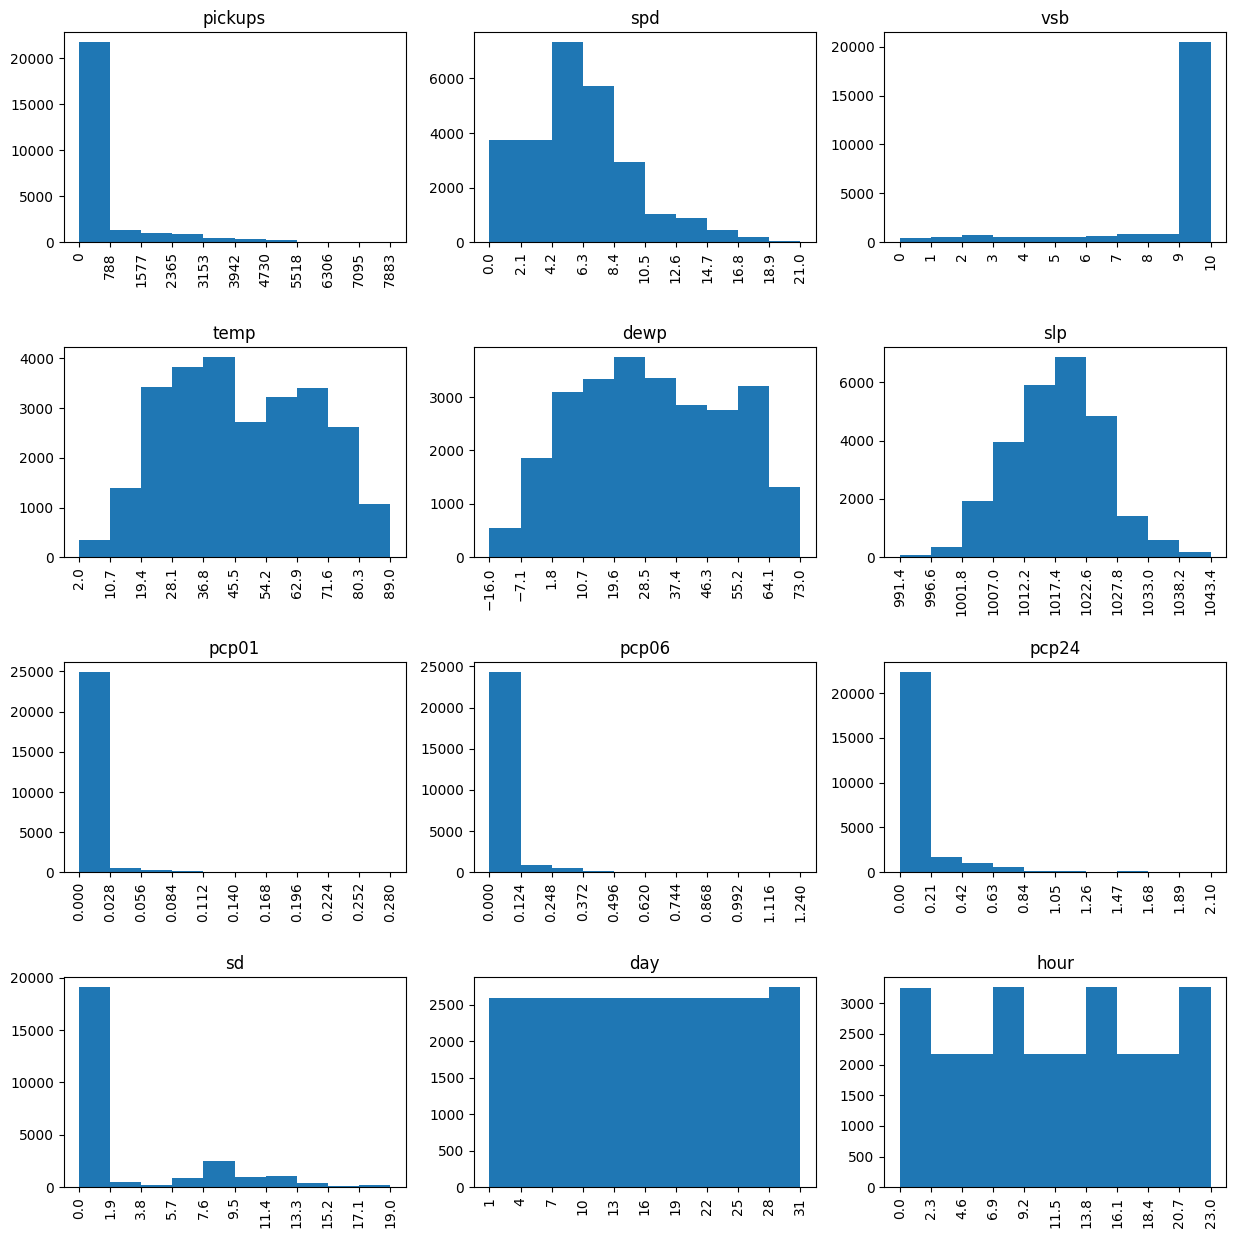

In [ ]:
# Matplotlib
fig, axes = plt.subplots(4,3, figsize=(15,15))
plt.subplots_adjust(hspace=0.5)

axes = axes.ravel()
for col, ax in zip(df[num_cols], axes):
  # To set exact values to bins edges
  n, bins, edges = ax.hist(df[col])
  ax.set_xticks(bins)
  ax.tick_params(axis='x',rotation=90)
  ax.set(title=f'{col}', xlabel=None)

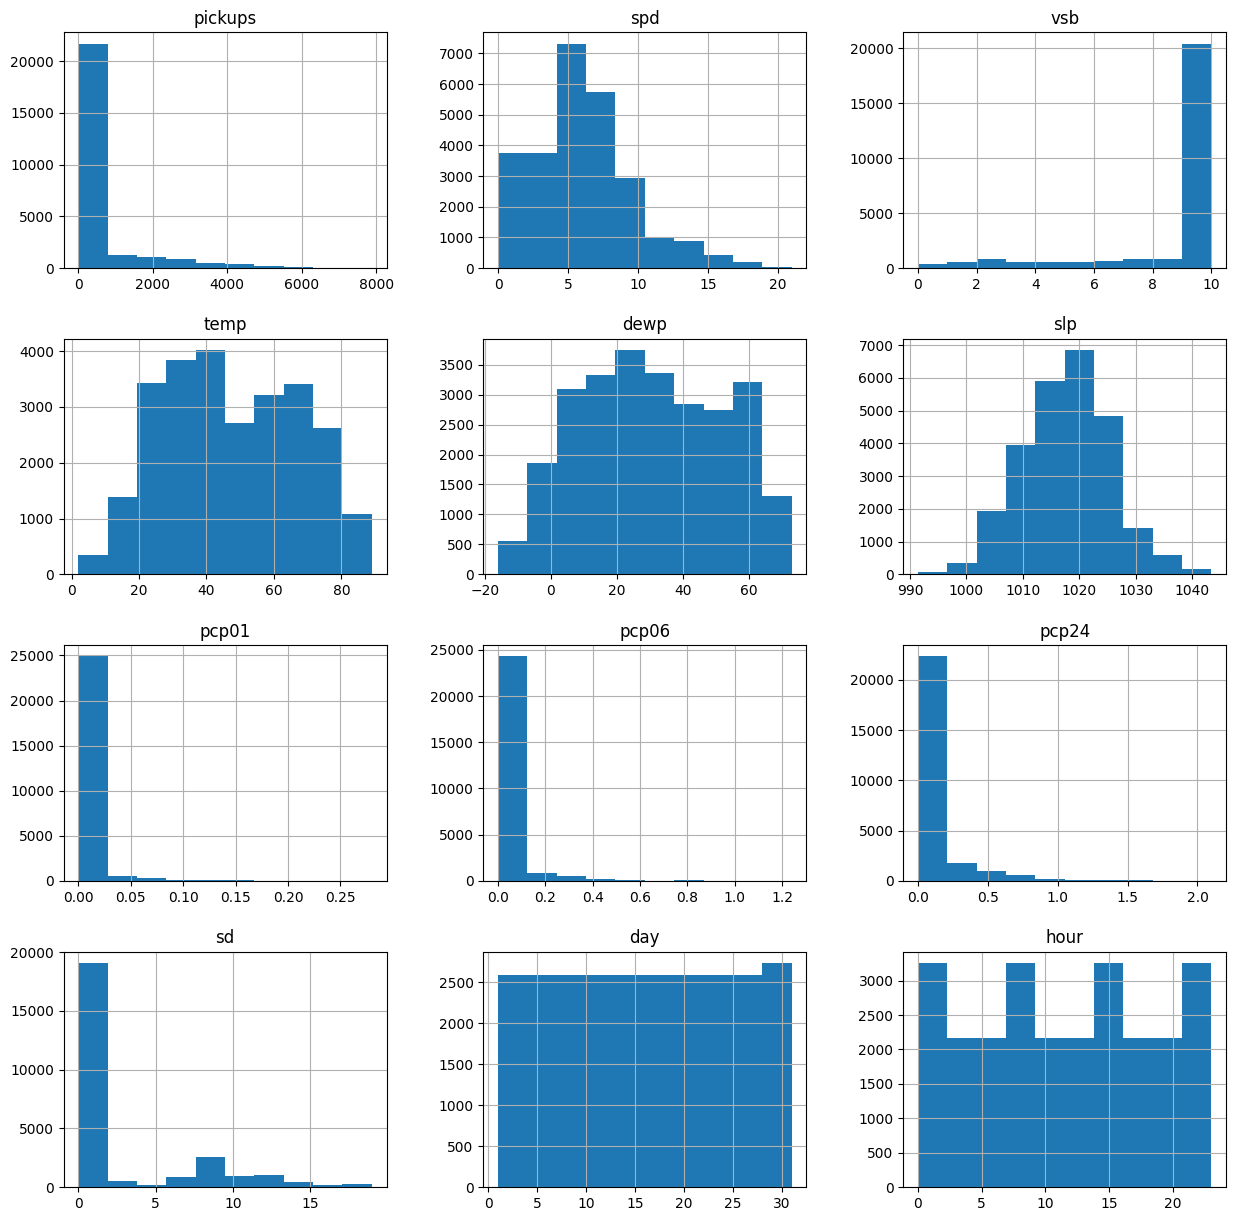

In [ ]:
# Pandas
df.hist(figsize=(15,15))
plt.show()

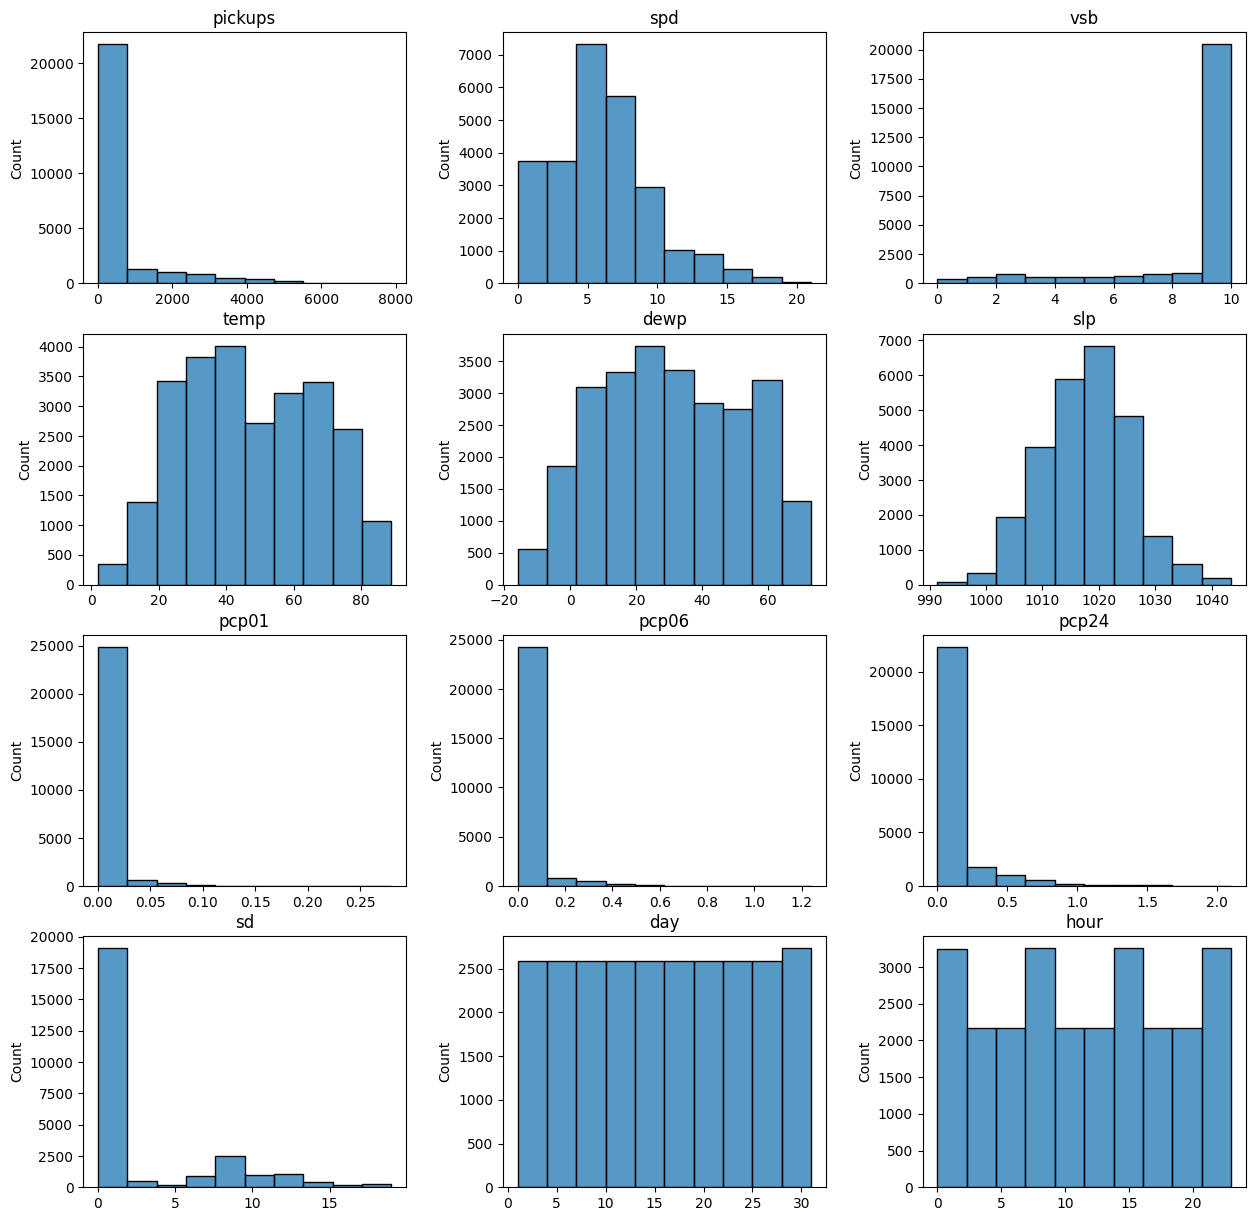

In [ ]:
# Let's combine platforms:
# - Matplotlib to create the sub-plots/graphs matrix and write titles
# - Seaborn to draw the histograms

fig, axes = plt.subplots(4,3, figsize=(15,15)) # ---> Matplotlib
plt.subplots_adjust(wspace=0.3)
axes = axes.ravel()
for col, ax in zip(df[num_cols], axes):
  sns.histplot(x=df[col], ax=ax, bins=10) # ---> Seaborn
  ax.set(title=f'{col}', xlabel=None) # ---> Matplotlib

**pickups**
* Distribution of pickups by hour is heavily skewed to the right.
* There are a lot of outliers.
* While the majority of pickups by hour fall at the lower end, there are observations where pickups by hour reached as high as 8000.

**vsb**
* Distribution of visibility is skewed to the left.
* However, there are outliers to the left, which means visibility is extremely low some days.
* It would be interesting to see how visibility affects the Uber's pickups frequency.

**sd**
* We noticed that there are snowfalls during the period we are analysed.
* There are outliers.
* Let's see how the snowfalls affect pickup services. It is probable that a few people go out during heavy snowfall, so pickups are likely to decrease.

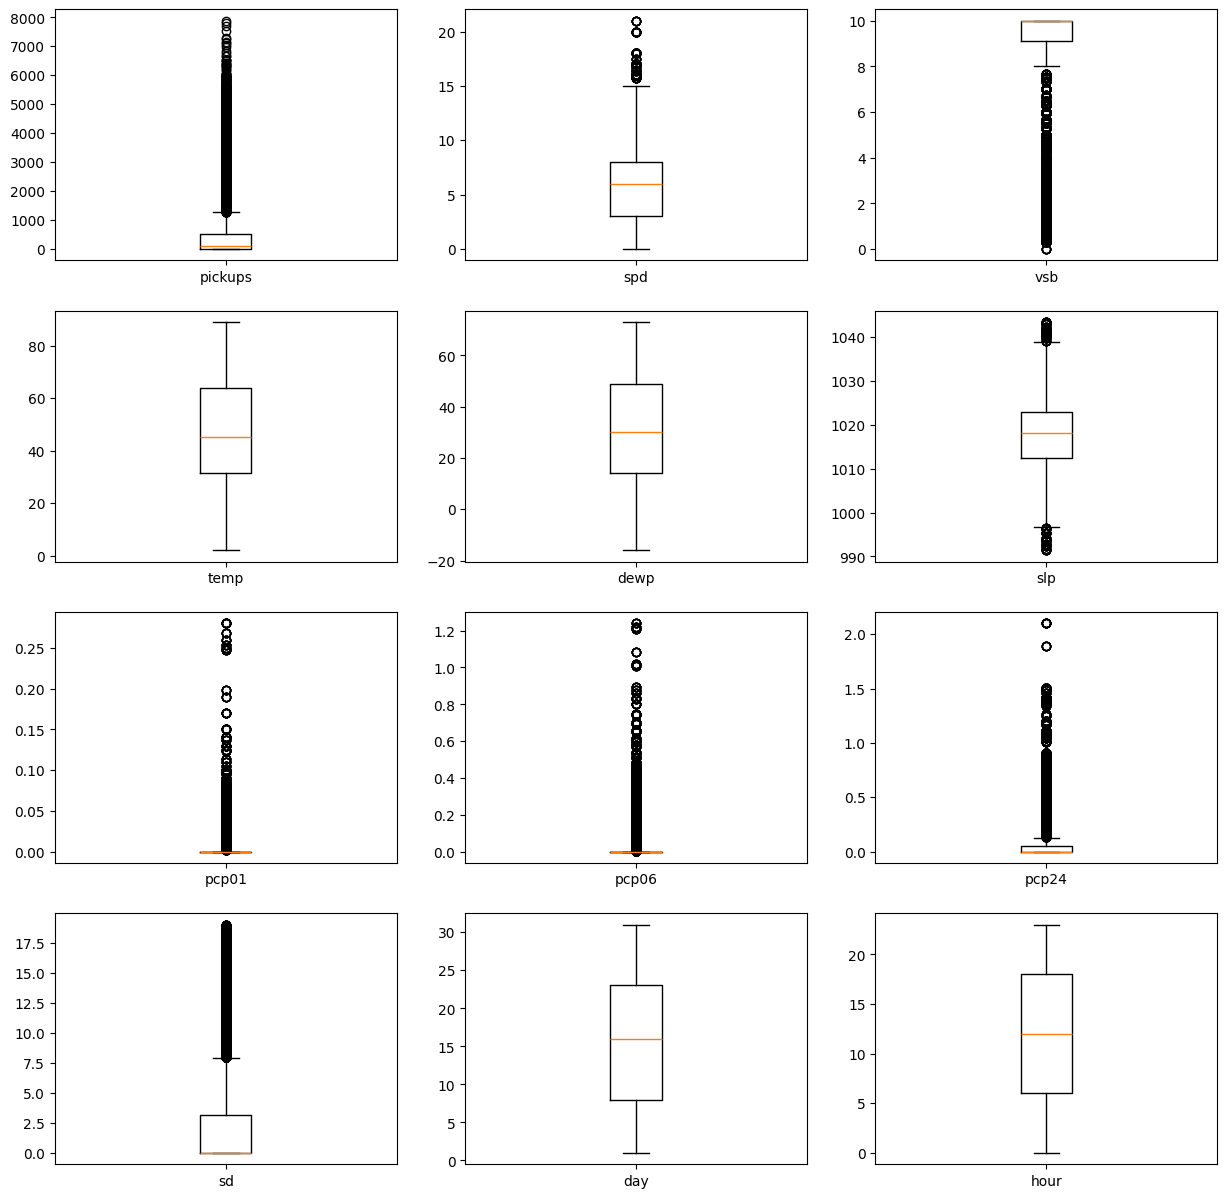

In [ ]:
# Matplotlib
fig, axes = plt.subplots(4,3, figsize=(15,15))
axes = axes.ravel()
for col, ax in zip(df[num_cols], axes):
  ax.boxplot(df[col], tick_labels=[f'{col}']) # ---> Matplotlib

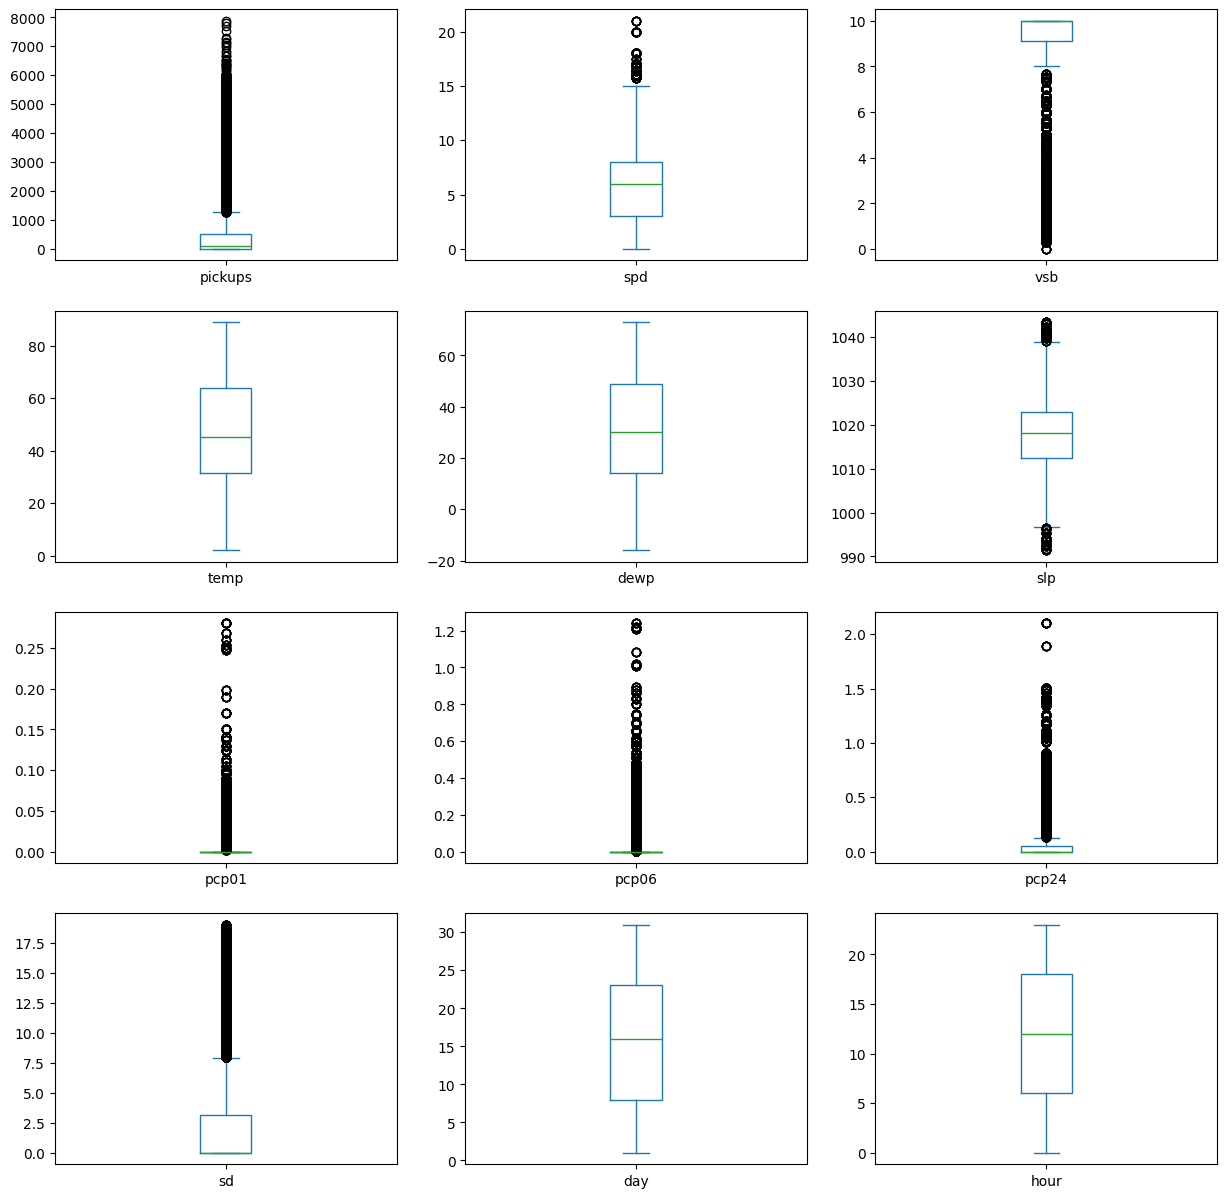

In [ ]:
# Let's combine platforms:
# - Matplotlib to create the sub-plots/graphs matrix
# - Pandas to draw the boxplots

fig, axes = plt.subplots(4,3, figsize=(15,15))
axes = axes.ravel()
for col, ax in zip(df[num_cols], axes):
  df[col].plot(kind='box', ax=ax) # ---> Pandas

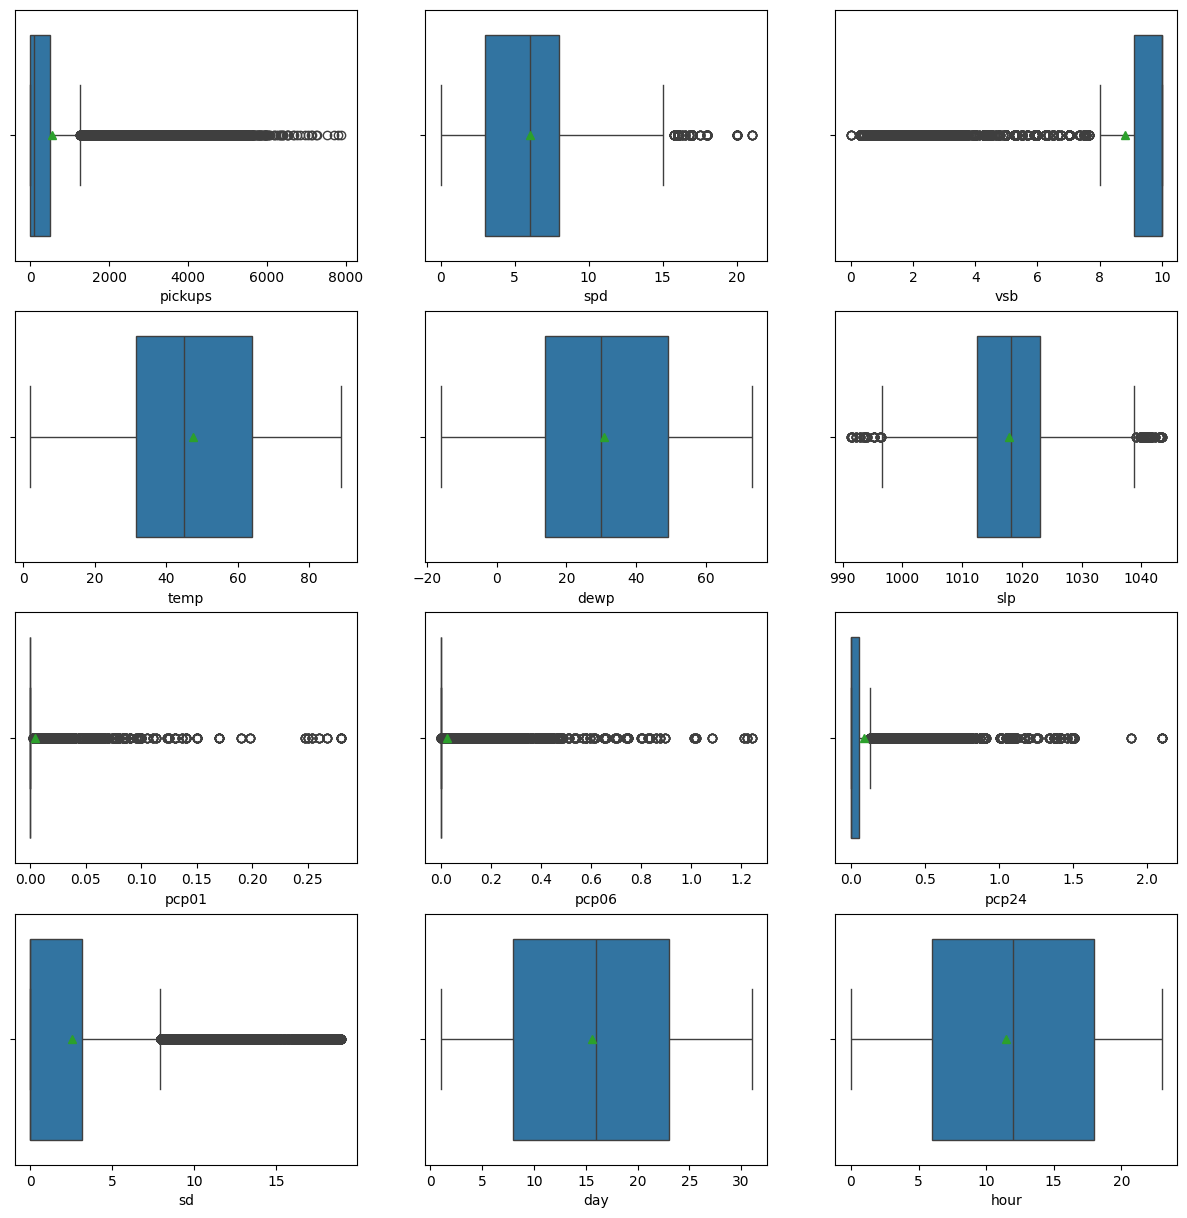

In [ ]:
# Let's combine platforms:
# - Matplotlib to create the sub-plots/graphs matrix and write titles
# - Seaborn to draw the boxplots

fig, axes = plt.subplots(4,3, figsize=(15,15))
axes = axes.ravel()
for col, ax in zip(df[num_cols], axes):
  sns.boxplot(x=df[col], ax=ax, showmeans=True) # ---> Seaborn
  ax.set(xlabel=f'{col}')

Now, let's analyze the categoric variables. It includes graphs with the three libs (just for references)

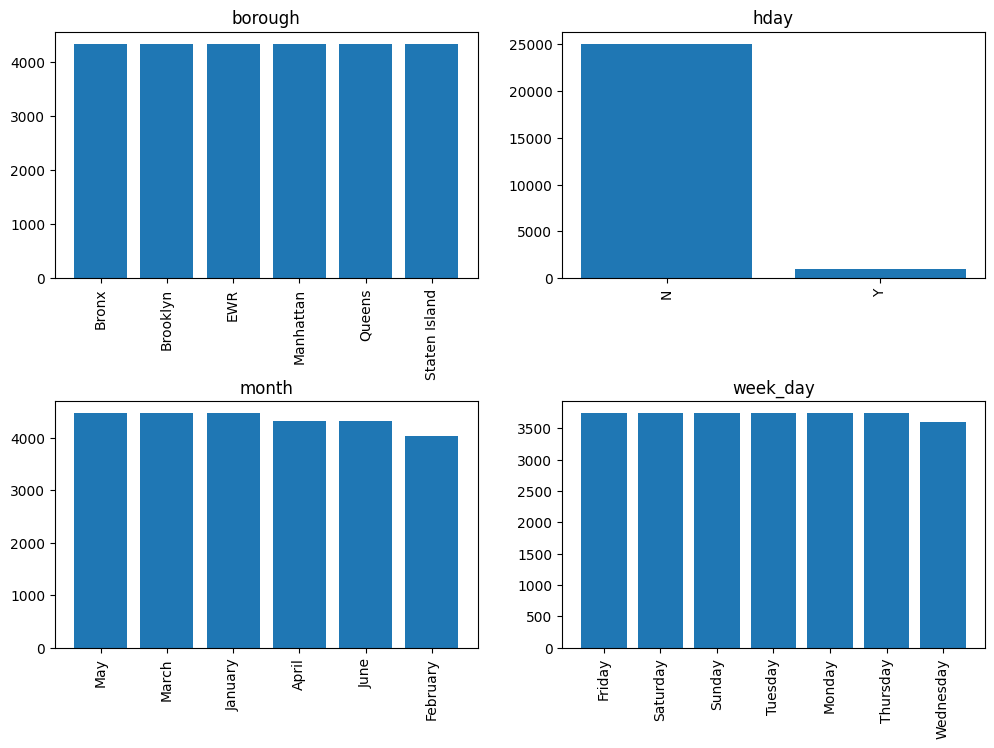

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(12,8))
plt.subplots_adjust(hspace=0.5)
axes = axes.ravel()
for col, ax in zip(df[cat_cols], axes):
  value_counts = df[col].value_counts()
  ax.bar(value_counts.index, value_counts.values) # ---> Matplotlib
  ax.set(title=f'{col}', xlabel=None)
  ax.tick_params(axis='x',rotation=90)

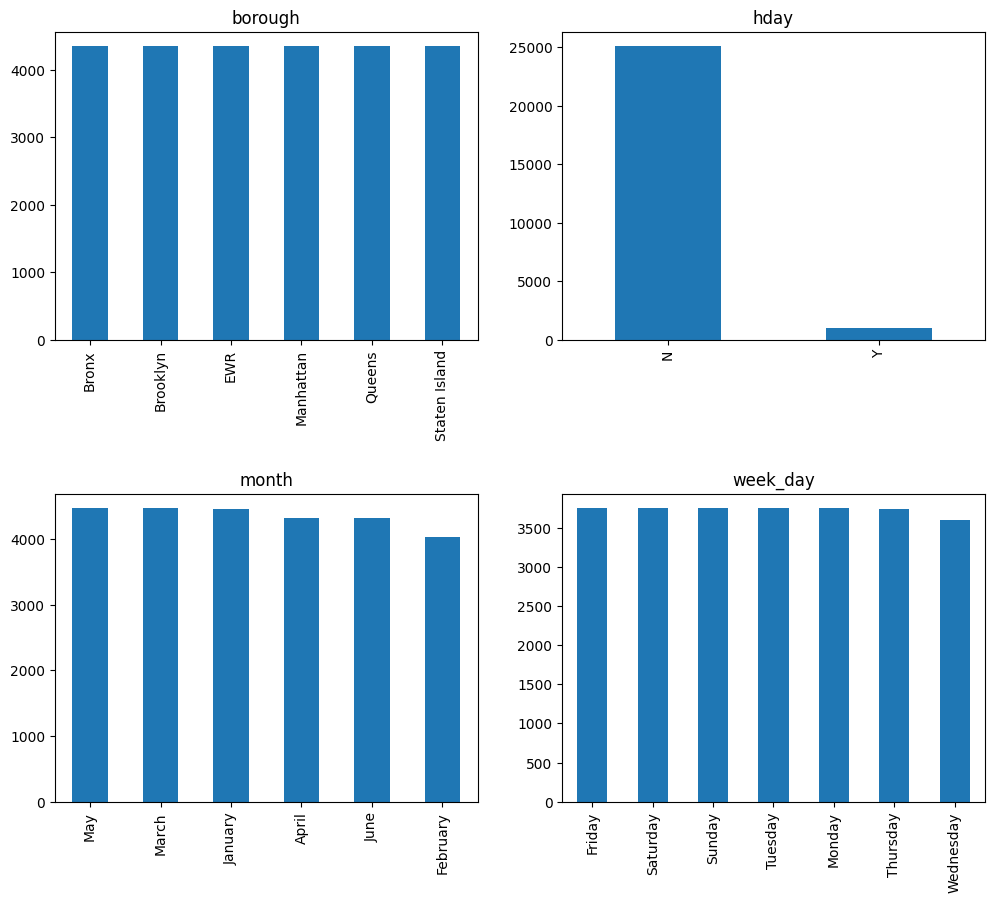

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(12,10))
plt.subplots_adjust(hspace=0.5)
axes = axes.ravel()
for col, ax in zip(df[cat_cols], axes):
  df[col].value_counts().plot(kind='bar', ax=ax) # ---> Pandas
  ax.set(title=f'{col}', xlabel=None)

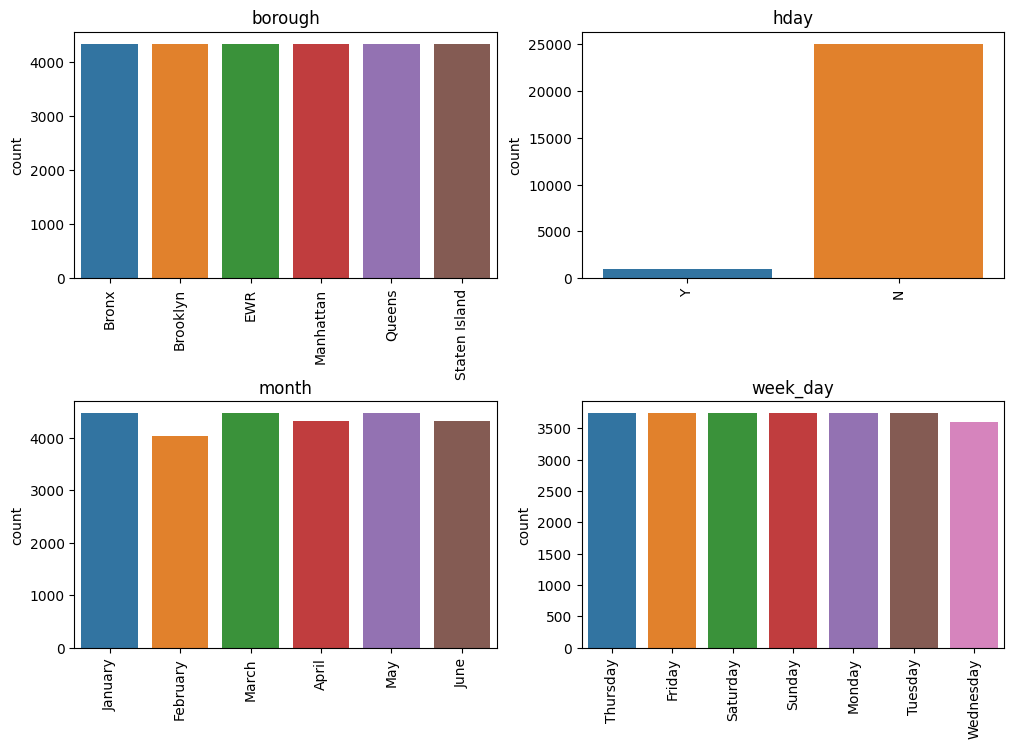

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(12,8))
plt.subplots_adjust(hspace=0.5)
axes = axes.ravel()
for col, ax in zip(df[cat_cols], axes):
  sns.countplot(x=df[col], hue=df[col], ax=ax) # ---> Seaborn
  ax.set(title=f'{col}', xlabel=None)
  ax.tick_params(axis='x',rotation=90)

* A few days were holidays during the period
* Observations were distributed uniformly among boroughs

## **Bivariate analysis**

Some analyses among numerical variables. It includes graphs with the three libs (just for references)

**vsb vs pickups**

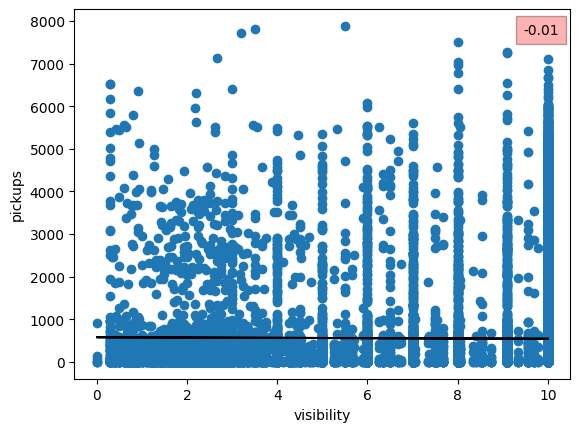

In [ ]:
# Matplotlib
plt.scatter(df['vsb'], df['pickups'])
plt.xlabel('visibility')
plt.ylabel('pickups')

# Set correlation value to the plot
r = df[['vsb','pickups']].corr().iloc[0,1]
plt.text(9.45,7700,round(r,2),bbox=dict(facecolor='red',alpha=0.3,pad=5))

# Calculate equation for trendline and place it on the plot
z = np.polyfit(df['vsb'], df['pickups'], 1)
p = np.poly1d(z)
plt.plot(df['vsb'], p(df['vsb']), color='black')

plt.show()

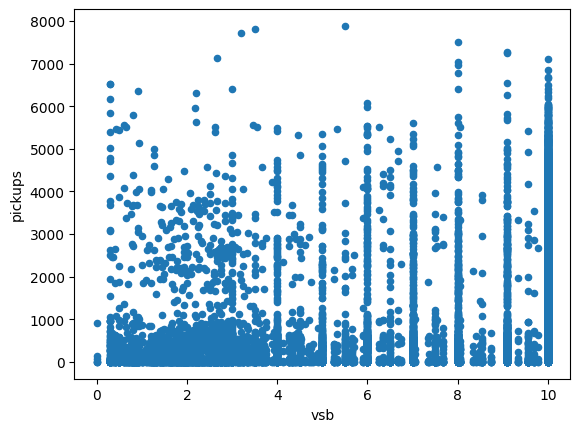

In [ ]:
# Pandas
df.plot(kind='scatter',x='vsb',y='pickups')
plt.show()

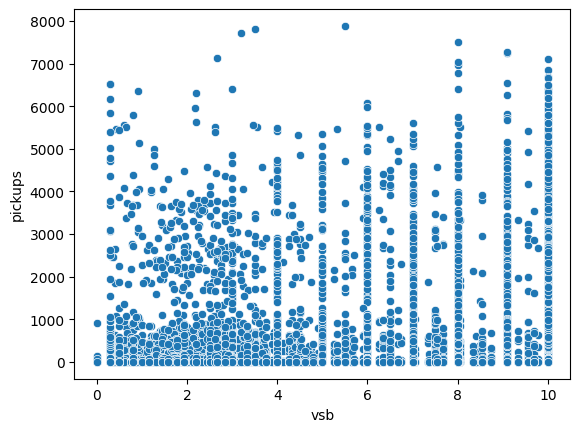

In [ ]:
# Seaborn
sns.scatterplot(y=df['pickups'], x=df['vsb'])
plt.show()

**sd vs pickups**

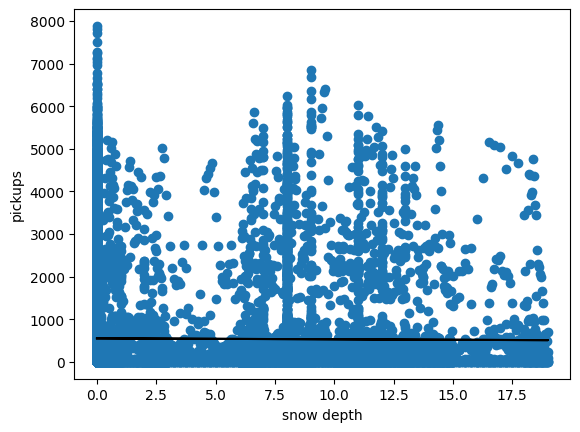

In [ ]:
# Matplotlib
plt.scatter(df['sd'], df['pickups'])
plt.xlabel('snow depth')
plt.ylabel('pickups')

# calculate equation for trendline
z = np.polyfit(df['sd'], df['pickups'], 1)
p = np.poly1d(z)

# add trendline to plot
plt.plot(df['sd'], p(df['sd']), color='black')
plt.show()

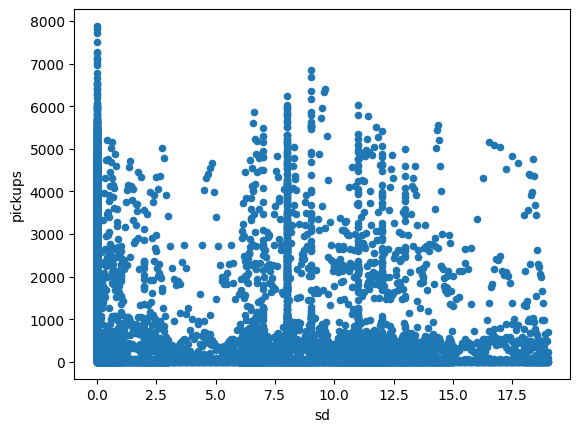

In [ ]:
# Pandas
df.plot(kind='scatter',x='sd',y='pickups')
plt.show()

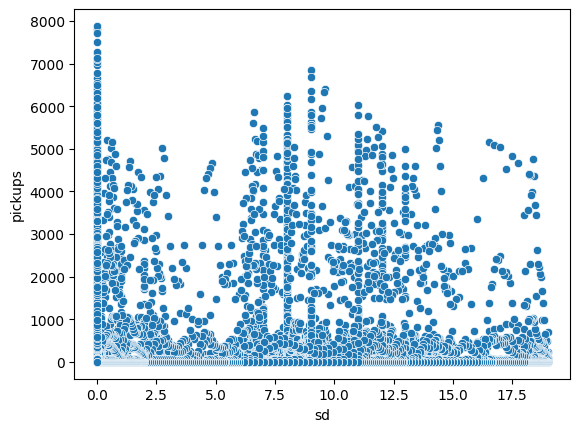

In [ ]:
# Seaborn
sns.scatterplot(x=df['sd'], y=df['pickups'])
plt.show()

* Based on the scatter plots above, there does not appear to be a strong relationship between number of pickups and these weather statistics.

Analysis between a numerical variable and a qualitative variable. It includes graphs with the three libs (just for references)

**borough vs pickups**

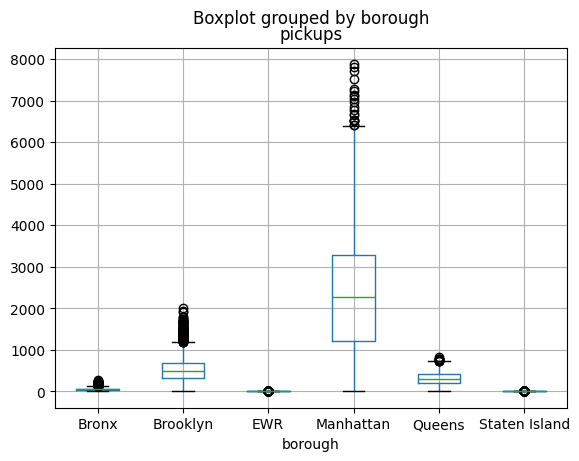

In [ ]:
df.boxplot(column='pickups', by='borough') # ---> Pandas
plt.show()

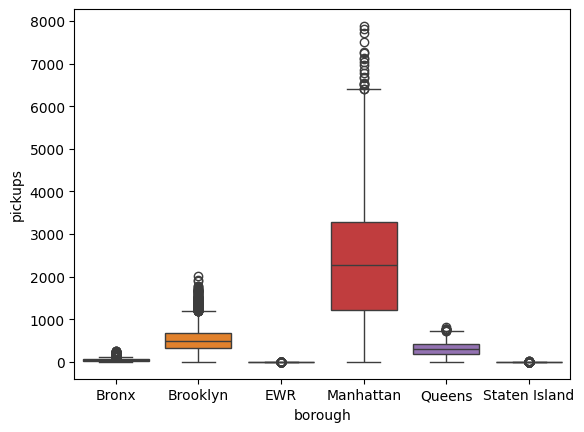

In [ ]:
sns.boxplot(x='borough', y='pickups', data=df, hue='borough', legend=False) # ---> Seaborn
plt.show()

* There is a clear difference to the number of passengers between boroughs.
* Manhattan has the biggest number of pickups.
* Brooklyn and Queens are distant followers.
* EWR and Staten Island have a very low number of pickups. Maybe passengers prefer to take the train or the ferry instead.

## **Multivariate Analysis**

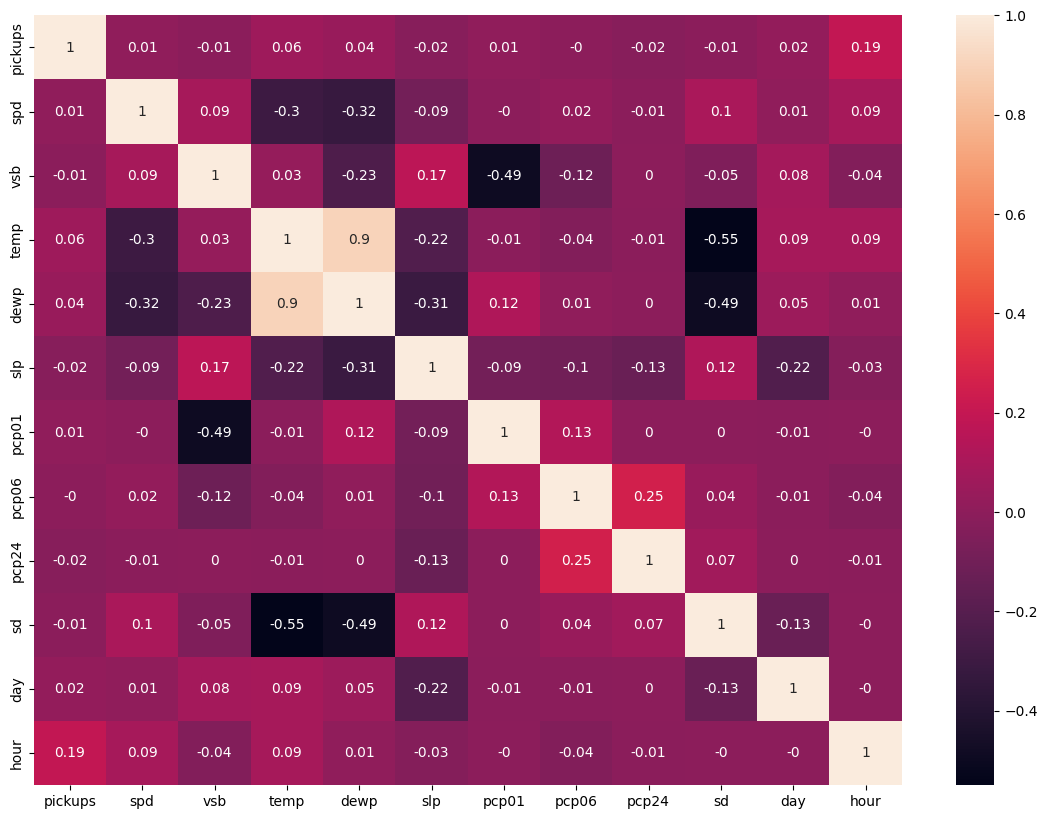

In [ ]:
plt.figure(figsize = (14, 10))
sns.heatmap(round(df.corr(numeric_only=True),2), annot = True) # ---> Seaborn
plt.show()

* Dew point is a humity indication, which has a correlation with temperature and we can see it as well at the heap map.
* Visibility has a negative correlation with precipitation. If rains are intensive during an specific hour, then visibility is low. This aligns with our intuitive compression.
* Snow depth, of course, has a negative correlation with temperature.
* Wind speed and sea level pression are negative correlated with temperature.
* It does not seem to be a solid relationship between number of pickups and weather statistics.
* It is important to mention that correlation does not imply causality. Check it out some spurious examples: https://hbr.org/2015/06/beware-spurious-correlations